# Tesla Valve Directional Asymmetry Notebook — Nexus v2

Δ **Purpose:** replace the reciprocal placeholder geometry with a real asymmetric Tesla-cell geometry and measure whether forward/reverse flow collapses into different attractors.

This notebook has three layers:

1. **Geometry builder** — creates an asymmetric main channel + angled side loop + reverse scoop.
2. **Reduced-order inertial eddy model** — fast, transparent, tunable; this is the main diagnostic engine.
3. **Optional LBM starter** — heavier CFD-ish sanity check; disabled by default.

Core observables:

$$
q_\Gamma=\frac{\langle \omega^2\rangle_\Gamma}{\langle |\mathbf{u}|^2\rangle_\Gamma+\epsilon}
$$

$$
Z=\frac{\Delta P}{Q^2+\epsilon}
$$

$$
A_q=\frac{q_R-q_F}{q_R+q_F+\epsilon}
$$

$$
D_q=\frac{q_R}{q_F+\epsilon},\qquad D_Z=\frac{Z_R}{Z_F+\epsilon}
$$

Ψ-lock target:

$$
q_R>q_F,\qquad Z_R>Z_F,\qquad A_q>0
$$

Ω condition:

$$
q_R\approx q_F,\qquad Z_R\approx Z_F
$$

That means the geometry is still operationally reciprocal.

In [10]:
# ============================================================
# 0. Imports and configuration
# ============================================================

import math
import json
import os
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# Global notebook settings
# --------------------------

NX = 320
NY = 180

DEFAULT_RE = 75.0
RE_SWEEP = [1, 5, 10, 25, 50, 75, 100, 150, 250]

SAVE_RESULTS = True
OUTDIR = Path("tesla_valve_nexus_v2_outputs")
OUTDIR.mkdir(exist_ok=True)

EPS = 1e-12

np.set_printoptions(precision=6, suppress=True)

print("Notebook initialized.")
print(f"Grid: {NX} x {NY}")
print(f"Output directory: {OUTDIR.resolve()}")

Notebook initialized.
Grid: 320 x 180
Output directory: D:\@User Data\Downloads\tesla_valve_nexus_v2_outputs


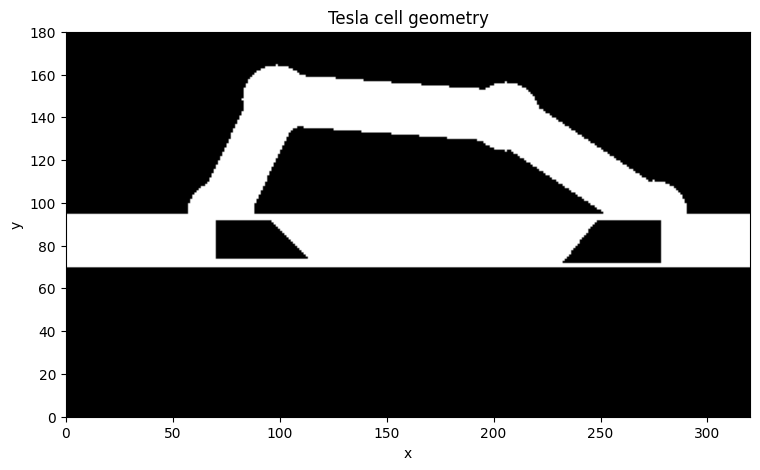

Fluid fraction: 0.22432291666666668
Geometry: {
  "nx": 320,
  "ny": 180,
  "main_y0": 70,
  "main_y1": 94,
  "A": [
    72,
    94
  ],
  "U1": [
    98,
    148
  ],
  "U2": [
    205,
    140
  ],
  "B": [
    274,
    94
  ],
  "loop_width": 24.0,
  "connector_radius": 16.0,
  "use_scoop_island": true,
  "use_return_island": true
}


In [11]:
# ============================================================
# 1. Geometry builder
# ============================================================

@dataclass
class TeslaGeom:
    nx: int = NX
    ny: int = NY

    # Main channel
    main_y0: int = 70
    main_y1: int = 94

    # Tesla side loop points.
    # Main flow left->right.
    # Forward branch entry at A is steep/high-turn.
    # Reverse branch entry at B is shallower/scoop-like.
    A: tuple = (72, 94)
    U1: tuple = (98, 148)
    U2: tuple = (205, 140)
    B: tuple = (274, 94)

    loop_width: float = 24.0
    connector_radius: float = 16.0

    # A small solid reverse-scoop island placed in the main channel near B.
    # It makes right->left flow strike a deflector and feed the side loop.
    use_scoop_island: bool = True

    # A small return-interference island near A.
    use_return_island: bool = True


def _canvas(geom: TeslaGeom):
    return np.zeros((geom.ny, geom.nx), dtype=bool)


def add_segment(mask, p0, p1, width):
    """Add a thick line segment to a boolean mask."""
    ny, nx = mask.shape
    xs = np.arange(nx)[None, :]
    ys = np.arange(ny)[:, None]
    x0, y0 = p0
    x1, y1 = p1
    vx = x1 - x0
    vy = y1 - y0
    denom = vx * vx + vy * vy + EPS
    t = ((xs - x0) * vx + (ys - y0) * vy) / denom
    t = np.clip(t, 0.0, 1.0)
    px = x0 + t * vx
    py = y0 + t * vy
    d2 = (xs - px) ** 2 + (ys - py) ** 2
    mask[d2 <= (width / 2.0) ** 2] = True
    return mask


def add_disk(mask, center, radius):
    ny, nx = mask.shape
    xs = np.arange(nx)[None, :]
    ys = np.arange(ny)[:, None]
    x, y = center
    mask[(xs - x) ** 2 + (ys - y) ** 2 <= radius ** 2] = True
    return mask


def polygon_mask(shape, points):
    """Return True inside polygon using ray casting."""
    ny, nx = shape
    xs = np.arange(nx)[None, :]
    ys = np.arange(ny)[:, None]
    inside = np.zeros((ny, nx), dtype=bool)
    pts = list(points)
    j = len(pts) - 1
    for i in range(len(pts)):
        xi, yi = pts[i]
        xj, yj = pts[j]
        cond = ((yi > ys) != (yj > ys)) & (
            xs < (xj - xi) * (ys - yi) / ((yj - yi) + EPS) + xi
        )
        inside ^= cond
        j = i
    return inside


def make_tesla_fluid_mask(geom: TeslaGeom):
    """
    True = fluid.
    False = solid.
    """
    fluid = _canvas(geom)

    # Main channel.
    fluid[geom.main_y0:geom.main_y1 + 1, :] = True

    # Side loop.
    loop = [geom.A, geom.U1, geom.U2, geom.B]
    for p0, p1 in zip(loop[:-1], loop[1:]):
        add_segment(fluid, p0, p1, geom.loop_width)

    # Round the junctions.
    for p in loop:
        add_disk(fluid, p, geom.connector_radius)

    # Reverse scoop island near B.
    # This is intentionally inside the main channel.
    # Reverse flow enters from the right and hits this wedge first.
    if geom.use_scoop_island:
        scoop = polygon_mask(
            fluid.shape,
            [
                (232, geom.main_y0 + 2),
                (278, geom.main_y0 + 2),
                (278, geom.main_y1 - 2),
                (248, geom.main_y1 - 2),
            ],
        )
        fluid[scoop] = False

    # Return island near A, forcing loop return to create local shear.
    if geom.use_return_island:
        ret = polygon_mask(
            fluid.shape,
            [
                (70, geom.main_y0 + 4),
                (112, geom.main_y0 + 4),
                (94, geom.main_y1 - 2),
                (70, geom.main_y1 - 2),
            ],
        )
        fluid[ret] = False

    return fluid


def plot_geometry(geom: TeslaGeom, ax=None, title="Tesla cell geometry"):
    fluid = make_tesla_fluid_mask(geom)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(fluid, origin="lower", cmap="gray", extent=[0, geom.nx, 0, geom.ny])
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    return ax


geom = TeslaGeom()
fluid = make_tesla_fluid_mask(geom)

fig, ax = plt.subplots(figsize=(12, 5))
plot_geometry(geom, ax=ax)
plt.show()

print("Fluid fraction:", fluid.mean())
print("Geometry:", json.dumps(asdict(geom), indent=2))

In [12]:
# ============================================================
# 2. Reduced-order inertial coupling model
# ============================================================

def unit(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    return v / (n + EPS)


def angle_deg(v, w):
    v = unit(v)
    w = unit(w)
    return math.degrees(math.acos(float(np.clip(np.dot(v, w), -1.0, 1.0))))


def re_activation(Re, half=35.0):
    """
    Smooth inertial activation.
    At low Re, passive valve behavior is nearly reciprocal.
    At higher Re, branch/collision terms turn on.
    """
    Re = float(Re)
    return Re / (Re + half + EPS)


def branch_couplings(geom: TeslaGeom, Re):
    """
    Estimate directional branch coupling from entry attack angle.

    Forward:
        main direction +x at A, side-loop entry A->U1.
    Reverse:
        main direction -x at B, side-loop entry B->U2.

    Smaller attack angle => more side-loop capture.
    Larger attack angle => less capture.

    This is a reduced-order model, not a Navier-Stokes solve.
    """
    A = np.array(geom.A, dtype=float)
    U1 = np.array(geom.U1, dtype=float)
    U2 = np.array(geom.U2, dtype=float)
    B = np.array(geom.B, dtype=float)

    theta_forward = angle_deg([1.0, 0.0], U1 - A)
    theta_reverse = angle_deg([-1.0, 0.0], U2 - B)

    inertial = re_activation(Re)

    # Capture function. Steep branch => low capture. Shallow scoop => high capture.
    def capture(theta):
        return math.exp(-((theta / 45.0) ** 2))

    raw_f = capture(theta_forward)
    raw_r = capture(theta_reverse)

    # Keep a small branch leakage even at low Re, then activate stronger capture with Re.
    alpha_min = 0.035
    alpha_max = 0.82

    alpha_f = alpha_min + (alpha_max - alpha_min) * inertial * raw_f
    alpha_r = alpha_min + (alpha_max - alpha_min) * inertial * raw_r

    return {
        "theta_forward_deg": theta_forward,
        "theta_reverse_deg": theta_reverse,
        "alpha_forward": alpha_f,
        "alpha_reverse": alpha_r,
        "inertial_activation": inertial,
    }


def reduced_order_case(direction, Re=DEFAULT_RE, geom=geom):
    """
    Fixed-throughput reduced-order model.

    Q_total is normalized to 1.
    Direction-dependent side-loop capture produces extra loop flow,
    curvature loss, and collision loss.

    direction:
        "forward" = left -> right
        "reverse" = right -> left
    """
    direction = direction.lower()
    assert direction in ("forward", "reverse")

    cpl = branch_couplings(geom, Re)
    alpha = cpl["alpha_forward"] if direction == "forward" else cpl["alpha_reverse"]
    inertial = cpl["inertial_activation"]

    Q_total = 1.0
    Q_loop = alpha * Q_total
    Q_main = Q_total - 0.35 * Q_loop  # loop steals useful straight-through coherence

    # Loss model.
    base_R = 1.00
    wall_R = 0.20
    main_turn_R = 0.10 * inertial

    # Loop path is longer and curved.
    loop_path_loss = 2.40 * Q_loop ** 2 * (0.25 + inertial)

    # Reverse collision: branch return collides with main path more strongly
    # because the B scoop captures more flow and returns it at A under a high angle.
    collision_gain = 3.25 if direction == "reverse" else 0.85
    collision_loss = collision_gain * (Q_loop * Q_main) ** 2 * inertial

    # Eddy burden model.
    q_base = 0.010
    q_loop = 0.030 * Q_loop ** 2 * (0.20 + inertial)
    q_collision = 0.120 * collision_loss
    q_gamma = q_base + q_loop + q_collision

    Z = base_R + wall_R + main_turn_R + loop_path_loss + collision_loss
    delta_P = Z * Q_total ** 2

    return {
        "direction": direction,
        "Re_proxy": Re,
        "Q_total": Q_total,
        "Q_main": Q_main,
        "Q_loop": Q_loop,
        "alpha_branch": alpha,
        "eddy_burden_qGamma": q_gamma,
        "impedance_Z": Z,
        "pressure_drop_dP": delta_P,
        "loop_path_loss": loop_path_loss,
        "collision_loss": collision_loss,
        **cpl,
    }


def compare_cases(Re=DEFAULT_RE, geom=geom):
    f = reduced_order_case("forward", Re, geom)
    r = reduced_order_case("reverse", Re, geom)

    qf = f["eddy_burden_qGamma"]
    qr = r["eddy_burden_qGamma"]
    zf = f["impedance_Z"]
    zr = r["impedance_Z"]
    dpf = f["pressure_drop_dP"]
    dpr = r["pressure_drop_dP"]

    out = {
        "Re_proxy": Re,
        "q_forward": qf,
        "q_reverse": qr,
        "Dq_qrev_qfwd": qr / (qf + EPS),
        "Z_forward": zf,
        "Z_reverse": zr,
        "DZ_zrev_zfwd": zr / (zf + EPS),
        "dP_forward": dpf,
        "dP_reverse": dpr,
        "DP_ratio": dpr / (dpf + EPS),
        "A_q": (qr - qf) / (qr + qf + EPS),
        "A_Z": (zr - zf) / (zr + zf + EPS),
        "alpha_forward": f["alpha_branch"],
        "alpha_reverse": r["alpha_branch"],
        "theta_forward_deg": f["theta_forward_deg"],
        "theta_reverse_deg": r["theta_reverse_deg"],
    }
    return f, r, out


f_case, r_case, summary = compare_cases(DEFAULT_RE, geom)

print("Directional coupling diagnostic:")
print(pd.Series(summary).to_string())

Directional coupling diagnostic:
Re_proxy             75.000000
q_forward             0.010994
q_reverse             0.036996
Dq_qrev_qfwd          3.365104
Z_forward             1.298489
Z_reverse             1.726977
DZ_zrev_zfwd          1.329990
dP_forward            1.298489
dP_reverse            1.726977
DP_ratio              1.329990
A_q                   0.541821
A_Z                   0.141627
alpha_forward         0.104519
alpha_reverse         0.340573
theta_forward_deg    64.290046
theta_reverse_deg    33.690068


In [13]:
# ============================================================
# 3. Vector-field renderer
# ============================================================

def segment_influence(shape, p0, p1, width):
    """
    Smooth tube influence around a segment.
    Returns weight field in [0, 1] and unit tangent vector p0->p1.
    """
    ny, nx = shape
    xs = np.arange(nx)[None, :]
    ys = np.arange(ny)[:, None]
    x0, y0 = p0
    x1, y1 = p1
    vx = x1 - x0
    vy = y1 - y0
    denom = vx * vx + vy * vy + EPS
    t = ((xs - x0) * vx + (ys - y0) * vy) / denom
    t = np.clip(t, 0.0, 1.0)
    px = x0 + t * vx
    py = y0 + t * vy
    d = np.sqrt((xs - px) ** 2 + (ys - py) ** 2)
    sigma = width / 2.25
    weight = np.exp(-(d ** 2) / (2 * sigma ** 2))
    weight[d > width * 1.15] = 0.0
    tangent = unit([vx, vy])
    return weight, tangent


def add_vortex(U, V, center, strength, radius):
    """
    Add localized eddy swirl.
    """
    ny, nx = U.shape
    xs = np.arange(nx)[None, :]
    ys = np.arange(ny)[:, None]
    cx, cy = center
    dx = xs - cx
    dy = ys - cy
    r2 = dx * dx + dy * dy
    envelope = np.exp(-r2 / (2 * radius ** 2))
    U += -strength * dy / (radius + EPS) * envelope
    V +=  strength * dx / (radius + EPS) * envelope
    return U, V


def render_field(direction, Re=DEFAULT_RE, geom=geom):
    """
    Render a qualitative vector field consistent with the reduced-order model.
    This is a field renderer for diagnostics/plots, not a full CFD solver.
    """
    direction = direction.lower()
    assert direction in ("forward", "reverse")

    fluid = make_tesla_fluid_mask(geom)
    ny, nx = fluid.shape

    U = np.zeros((ny, nx), dtype=float)
    V = np.zeros((ny, nx), dtype=float)
    W = np.zeros((ny, nx), dtype=float)

    case = reduced_order_case(direction, Re, geom)
    alpha = case["alpha_branch"]
    sign = +1.0 if direction == "forward" else -1.0

    # Main channel field.
    main = np.zeros_like(fluid)
    main[geom.main_y0:geom.main_y1 + 1, :] = True
    main &= fluid

    U[main] += sign * case["Q_main"]
    W[main] += 1.0

    # Side loop field.
    loop_points = [geom.A, geom.U1, geom.U2, geom.B]
    if direction == "forward":
        loop_path = loop_points
    else:
        loop_path = list(reversed(loop_points))

    for p0, p1 in zip(loop_path[:-1], loop_path[1:]):
        wt, tang = segment_influence(fluid.shape, p0, p1, geom.loop_width)
        wt *= fluid
        U += wt * tang[0] * case["Q_loop"] * 1.45
        V += wt * tang[1] * case["Q_loop"] * 1.45
        W += wt

    # Normalize additive overlaps.
    nonzero = W > EPS
    U[nonzero] /= W[nonzero]
    V[nonzero] /= W[nonzero]

    # Add collision/eddy structures.
    inertial = re_activation(Re)
    if direction == "reverse":
        # Return collision near A and scoop collision near B.
        U, V = add_vortex(U, V, center=(geom.A[0] + 20, geom.main_y1 - 2),
                          strength=0.85 * alpha * inertial, radius=18)
        U, V = add_vortex(U, V, center=(geom.B[0] - 20, geom.main_y1 - 3),
                          strength=-0.65 * alpha * inertial, radius=20)
    else:
        # Forward has only weak shedding.
        U, V = add_vortex(U, V, center=(geom.B[0] - 25, geom.main_y1 - 4),
                          strength=0.18 * alpha * inertial, radius=20)

    U[~fluid] = np.nan
    V[~fluid] = np.nan

    speed = np.sqrt(U ** 2 + V ** 2)

    # Vorticity.
    U0 = np.nan_to_num(U, nan=0.0)
    V0 = np.nan_to_num(V, nan=0.0)
    omega = np.gradient(V0, axis=1) - np.gradient(U0, axis=0)
    omega[~fluid] = np.nan

    # Pressure proxy: main gradient + eddy hotspots.
    xs = np.linspace(0, 1, nx)[None, :]
    if direction == "forward":
        P = 1 - xs
    else:
        P = xs
    P = np.repeat(P, ny, axis=0)
    P += 0.25 * case["collision_loss"] * np.nan_to_num(speed, nan=0.0)
    P[~fluid] = np.nan

    # Render-derived q.
    q_render = np.nanmean(omega[fluid] ** 2) / (np.nanmean(speed[fluid] ** 2) + EPS)

    case = dict(case)
    case["qGamma_rendered_field"] = q_render
    case["max_speed_rendered"] = np.nanmax(speed)
    case["mean_speed_rendered"] = np.nanmean(speed[fluid])

    return {
        "U": U,
        "V": V,
        "speed": speed,
        "omega": omega,
        "P": P,
        "fluid": fluid,
        "case": case,
    }


def plot_case(field, title=None, save_path=None):
    U = field["U"]
    V = field["V"]
    speed = field["speed"]
    omega = field["omega"]
    P = field["P"]
    fluid = field["fluid"]
    case = field["case"]
    ny, nx = fluid.shape

    if title is None:
        title = f"Tesla Valve Flow Simulation - {case['direction'].upper()} Direction"

    x = np.arange(nx)
    y = np.arange(ny)
    X, Y = np.meshgrid(x, y)

    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(title, fontsize=16, fontweight="bold")

    ax1 = fig.add_subplot(2, 2, 1)
    im1 = ax1.imshow(speed, origin="lower", extent=[0, nx, 0, ny])
    ax1.contour(fluid.astype(float), levels=[0.5], colors="cyan", linewidths=0.8, origin="lower", extent=[0, nx, 0, ny])
    ax1.set_title(f"Velocity Magnitude ({case['direction'].upper()})")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label="|u|")

    ax2 = fig.add_subplot(2, 2, 2)
    vmax = np.nanpercentile(np.abs(omega), 98)
    im2 = ax2.imshow(omega, origin="lower", extent=[0, nx, 0, ny], vmin=-vmax, vmax=vmax, cmap="coolwarm")
    ax2.contour(fluid.astype(float), levels=[0.5], colors="k", linewidths=0.6, origin="lower", extent=[0, nx, 0, ny])
    ax2.set_title(f"Vorticity ω = ∇×u ({case['direction'].upper()})")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label="ω")

    ax3 = fig.add_subplot(2, 2, 3)
    U0 = np.nan_to_num(U, nan=0.0)
    V0 = np.nan_to_num(V, nan=0.0)
    lw = 0.5 + 2.0 * np.nan_to_num(speed / (np.nanmax(speed) + EPS), nan=0.0)
    try:
        ax3.streamplot(X, Y, U0, V0, density=1.3, linewidth=lw, arrowsize=0.8)
    except Exception:
        skip = 8
        ax3.quiver(X[::skip, ::skip], Y[::skip, ::skip], U0[::skip, ::skip], V0[::skip, ::skip])
    ax3.contour(fluid.astype(float), levels=[0.5], colors="k", linewidths=0.6, origin="lower", extent=[0, nx, 0, ny])
    ax3.set_xlim(0, nx)
    ax3.set_ylim(0, ny)
    ax3.set_title(f"Flow Streamlines ({case['direction'].upper()})")
    ax3.set_xlabel("x")
    ax3.set_ylabel("y")

    ax4 = fig.add_subplot(2, 2, 4)
    im4 = ax4.imshow(P, origin="lower", extent=[0, nx, 0, ny], cmap="coolwarm")
    ax4.contour(fluid.astype(float), levels=[0.5], colors="k", linewidths=0.6, origin="lower", extent=[0, nx, 0, ny])
    ax4.set_title(f"Pressure Proxy ({case['direction'].upper()})")
    ax4.set_xlabel("x")
    ax4.set_ylabel("y")
    fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04, label="P proxy")

    fig.text(
        0.5, 0.015,
        f"Eddy burden qΓ(model)={case['eddy_burden_qGamma']:.6f} | "
        f"qΓ(field)={case['qGamma_rendered_field']:.6f} | "
        f"Z={case['impedance_Z']:.6f} | "
        f"α_branch={case['alpha_branch']:.3f}",
        ha="center",
        bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.6),
        fontsize=11,
    )

    plt.tight_layout(rect=[0, 0.04, 1, 0.95])

    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print(f"Saved: {save_path}")

    return fig

TESLA VALVE DIRECTIONAL ASYMMETRY EXPERIMENT — NEXUS v2
Re proxy: 75.0

FORWARD FLOW:
  Branch coupling α:       0.104519
  Eddy burden qΓ:          0.010994
  Rendered qΓ:             0.029262
  Pressure drop ΔP:        1.298489
  Impedance Z:             1.298489

REVERSE FLOW:
  Branch coupling α:       0.340573
  Eddy burden qΓ:          0.036996
  Rendered qΓ:             0.027021
  Pressure drop ΔP:        1.726977
  Impedance Z:             1.726977

ASYMMETRY METRICS:
  Eddy burden ratio Dq=qR/qF:      3.3651
  Impedance ratio DZ=ZR/ZF:        1.3300
  Pressure ratio DPR=ΔPR/ΔPF:      1.3300
  Asymmetry A_q:                   0.5418
  Asymmetry A_Z:                   0.1416

Ψ-LOCK: geometry is directionally folding.
Saved: tesla_valve_nexus_v2_outputs\tesla_v2_forward.png


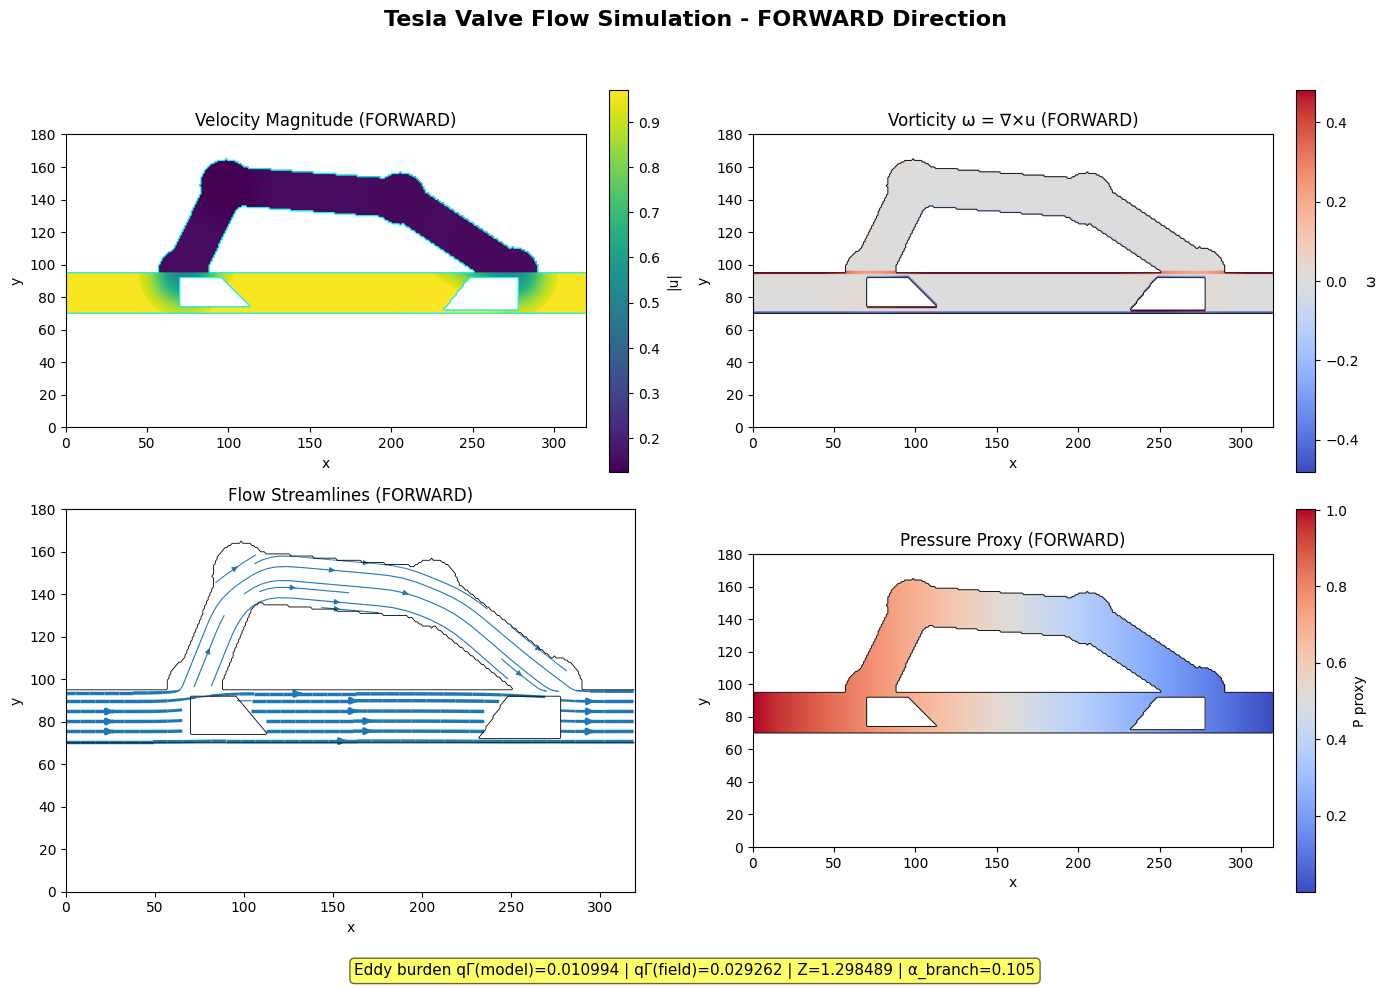

Saved: tesla_valve_nexus_v2_outputs\tesla_v2_reverse.png


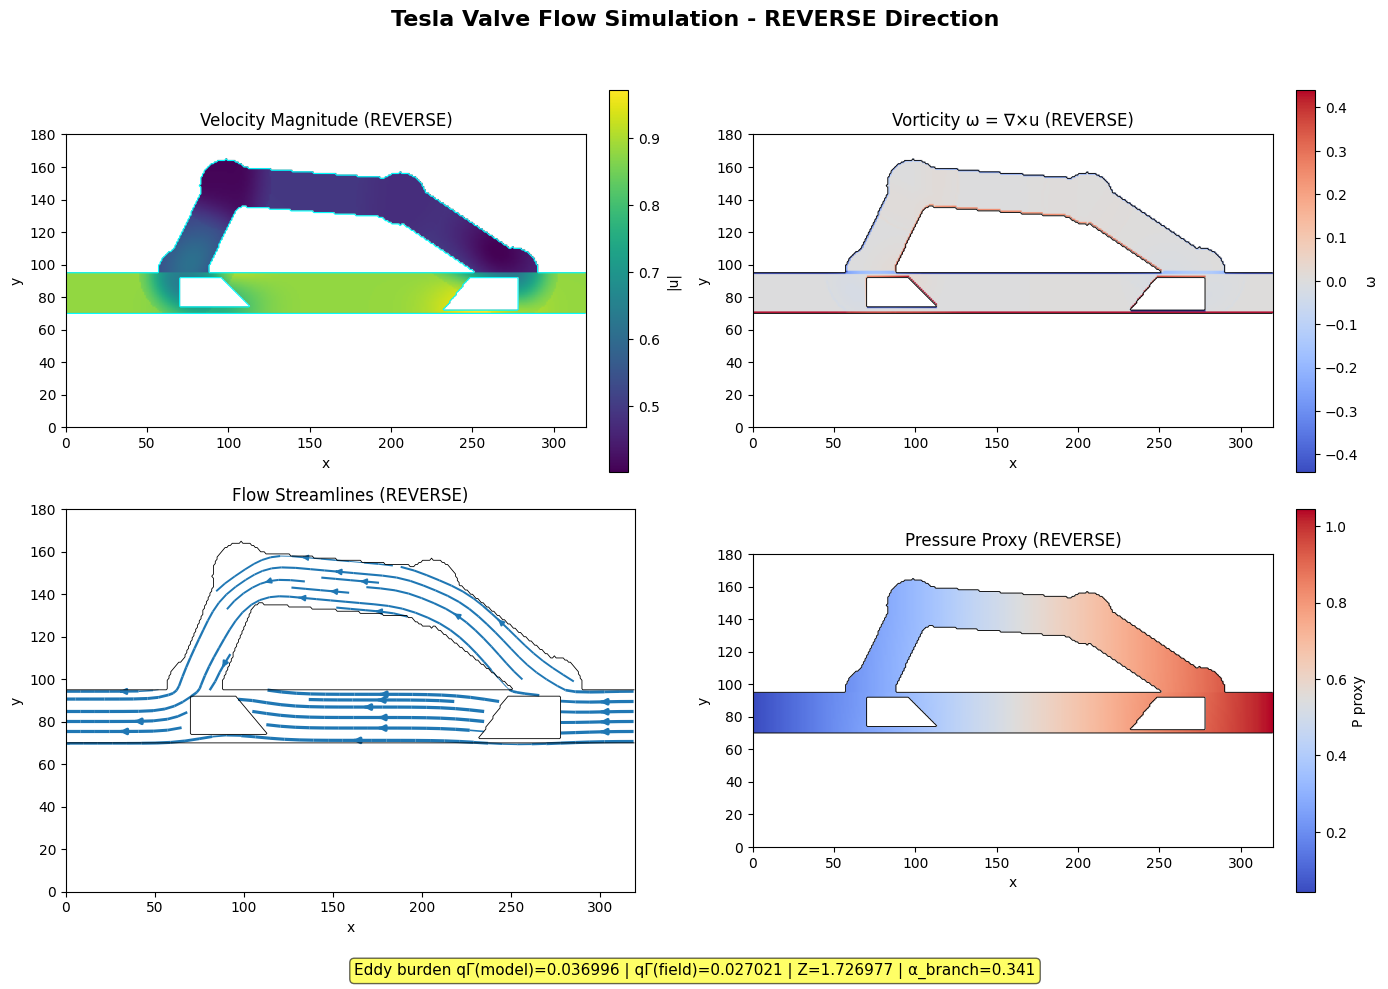

Saved: tesla_valve_nexus_v2_outputs\tesla_v2_single_case_summary.json


In [14]:
# ============================================================
# 4. Run forward/reverse at one Reynolds proxy
# ============================================================

Re = DEFAULT_RE

forward_field = render_field("forward", Re=Re, geom=geom)
reverse_field = render_field("reverse", Re=Re, geom=geom)

f, r, summary = compare_cases(Re, geom)

print("=" * 72)
print("TESLA VALVE DIRECTIONAL ASYMMETRY EXPERIMENT — NEXUS v2")
print("=" * 72)
print(f"Re proxy: {Re}")
print()
print("FORWARD FLOW:")
print(f"  Branch coupling α:       {f['alpha_branch']:.6f}")
print(f"  Eddy burden qΓ:          {f['eddy_burden_qGamma']:.6f}")
print(f"  Rendered qΓ:             {forward_field['case']['qGamma_rendered_field']:.6f}")
print(f"  Pressure drop ΔP:        {f['pressure_drop_dP']:.6f}")
print(f"  Impedance Z:             {f['impedance_Z']:.6f}")
print()
print("REVERSE FLOW:")
print(f"  Branch coupling α:       {r['alpha_branch']:.6f}")
print(f"  Eddy burden qΓ:          {r['eddy_burden_qGamma']:.6f}")
print(f"  Rendered qΓ:             {reverse_field['case']['qGamma_rendered_field']:.6f}")
print(f"  Pressure drop ΔP:        {r['pressure_drop_dP']:.6f}")
print(f"  Impedance Z:             {r['impedance_Z']:.6f}")
print()
print("ASYMMETRY METRICS:")
print(f"  Eddy burden ratio Dq=qR/qF:      {summary['Dq_qrev_qfwd']:.4f}")
print(f"  Impedance ratio DZ=ZR/ZF:        {summary['DZ_zrev_zfwd']:.4f}")
print(f"  Pressure ratio DPR=ΔPR/ΔPF:      {summary['DP_ratio']:.4f}")
print(f"  Asymmetry A_q:                   {summary['A_q']:.4f}")
print(f"  Asymmetry A_Z:                   {summary['A_Z']:.4f}")
print()
if summary["Dq_qrev_qfwd"] > 1.25 and summary["DZ_zrev_zfwd"] > 1.10:
    print("Ψ-LOCK: geometry is directionally folding.")
else:
    print("Ω: weak asymmetry. Refine side-loop angle, scoop, or Re proxy.")

# Plots.
fig1 = plot_case(forward_field, save_path=OUTDIR / "tesla_v2_forward.png" if SAVE_RESULTS else None)
plt.show()

fig2 = plot_case(reverse_field, save_path=OUTDIR / "tesla_v2_reverse.png" if SAVE_RESULTS else None)
plt.show()

if SAVE_RESULTS:
    with open(OUTDIR / "tesla_v2_single_case_summary.json", "w", encoding="utf-8") as fobj:
        json.dump(summary, fobj, indent=2)
    print(f"Saved: {OUTDIR / 'tesla_v2_single_case_summary.json'}")

,Re_proxy,q_forward,q_reverse,Dq_qrev_qfwd,Z_forward,Z_reverse,DZ_zrev_zfwd,dP_forward,dP_reverse,DP_ratio,A_q,A_Z,alpha_forward,alpha_reverse,theta_forward_deg,theta_reverse_deg
0,1,0.010014,0.010039,1.002521,1.203765,1.204475,1.000590,1.203765,1.204475,1.000590,0.001259,0.000295,0.037832,0.047449,64.290046,33.690068
1,5,0.010050,0.010459,1.040697,1.214786,1.223111,1.006853,1.214786,1.223111,1.006853,0.019943,0.003415,0.047745,0.091022,64.290046,33.690068
2,10,0.010114,0.011655,1.152316,1.226593,1.254633,1.022860,1.226593,1.254633,1.022860,0.070768,0.011301,0.057658,0.134594,64.290046,33.690068
3,25,0.010353,0.017707,1.710433,1.253285,1.376984,1.098699,1.253285,1.376984,1.098699,0.262111,0.047029,0.077484,0.221739,64.290046,33.690068
4,50,0.010719,0.028515,2.660155,1.281186,1.574949,1.229289,1.281186,1.574949,1.229289,0.453575,0.102853,0.094977,0.298631,64.290046,33.690068
5,75,0.010994,0.036996,3.365104,1.298489,1.726977,1.329990,1.298489,1.726977,1.329990,0.541821,0.141627,0.104519,0.340573,64.290046,33.690068
6,100,0.011198,0.043354,3.871694,1.310230,1.840578,1.404775,1.310230,1.840578,1.404775,0.589465,0.168322,0.110527,0.366980,64.290046,33.690068
7,150,0.011473,0.051980,4.530738,1.325107,1.994870,1.505441,1.325107,1.994870,1.505441,0.638385,0.201737,0.117671,0.398384,64.290046,33.690068
8,250,0.011768,0.061246,5.204505,1.340173,2.161279,1.612687,1.340173,2.161279,1.612687,0.677654,0.234504,0.124440,0.428134,64.290046,33.690068


Saved: tesla_valve_nexus_v2_outputs\tesla_v2_re_sweep.csv
Saved: tesla_valve_nexus_v2_outputs\tesla_v2_re_sweep_ratios.png


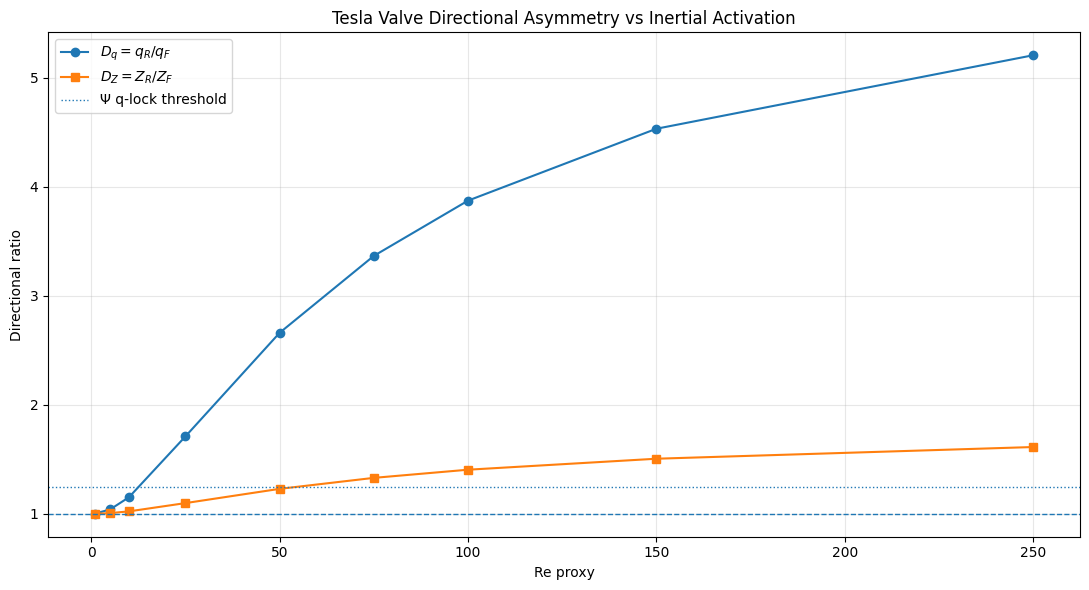

Saved: tesla_valve_nexus_v2_outputs\tesla_v2_re_sweep_asymmetry.png


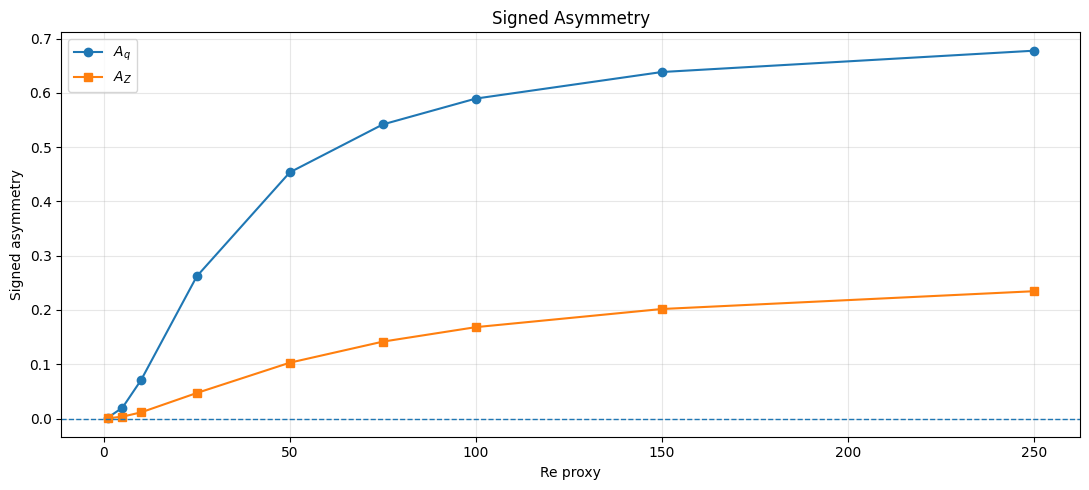

In [15]:
# ============================================================
# 5. Sweep Reynolds proxy and plot asymmetry phase curve
# ============================================================

rows = []
for Re in RE_SWEEP:
    _, _, s = compare_cases(Re, geom)
    rows.append(s)

df = pd.DataFrame(rows)
display(df)

if SAVE_RESULTS:
    df.to_csv(OUTDIR / "tesla_v2_re_sweep.csv", index=False)
    print(f"Saved: {OUTDIR / 'tesla_v2_re_sweep.csv'}")

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(df["Re_proxy"], df["Dq_qrev_qfwd"], marker="o", label=r"$D_q=q_R/q_F$")
ax.plot(df["Re_proxy"], df["DZ_zrev_zfwd"], marker="s", label=r"$D_Z=Z_R/Z_F$")
ax.axhline(1.0, linestyle="--", linewidth=1)
ax.axhline(1.25, linestyle=":", linewidth=1, label="Ψ q-lock threshold")
ax.set_xlabel("Re proxy")
ax.set_ylabel("Directional ratio")
ax.set_title("Tesla Valve Directional Asymmetry vs Inertial Activation")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

if SAVE_RESULTS:
    fig.savefig(OUTDIR / "tesla_v2_re_sweep_ratios.png", dpi=180, bbox_inches="tight")
    print(f"Saved: {OUTDIR / 'tesla_v2_re_sweep_ratios.png'}")

plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["Re_proxy"], df["A_q"], marker="o", label=r"$A_q$")
ax.plot(df["Re_proxy"], df["A_Z"], marker="s", label=r"$A_Z$")
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_xlabel("Re proxy")
ax.set_ylabel("Signed asymmetry")
ax.set_title("Signed Asymmetry")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

if SAVE_RESULTS:
    fig.savefig(OUTDIR / "tesla_v2_re_sweep_asymmetry.png", dpi=180, bbox_inches="tight")
    print(f"Saved: {OUTDIR / 'tesla_v2_re_sweep_asymmetry.png'}")

plt.show()

Top geometry score: 4.237177557672388
Top metrics:
  score: 4.237177557672388
  Re_proxy: 75.0
  q_forward: 0.010269507951776351
  q_reverse: 0.07017478097313289
  Dq_qrev_qfwd: 6.833314828307933
  Z_forward: 1.2762440698365012
  Z_reverse: 2.3759253360301904
  DZ_zrev_zfwd: 1.8616543592110142
  dP_forward: 1.2762440698365012
  dP_reverse: 2.3759253360301904
  DP_ratio: 1.8616543592110142
  A_q: 0.744680247923261
  A_Z: 0.3011035754329759
  alpha_forward: 0.05371429392541846
  alpha_reverse: 0.548407846450638
  theta_forward_deg: 82.40535663141632
  theta_reverse_deg: 9.180541957984275
Top geometry:
{
  "nx": 320,
  "ny": 180,
  "main_y0": 70,
  "main_y1": 94,
  "A": [
    72,
    94
  ],
  "U1": [
    80,
    154
  ],
  "U2": [
    175,
    110
  ],
  "B": [
    274,
    94
  ],
  "loop_width": 24.0,
  "connector_radius": 16.0,
  "use_scoop_island": true,
  "use_return_island": true
}


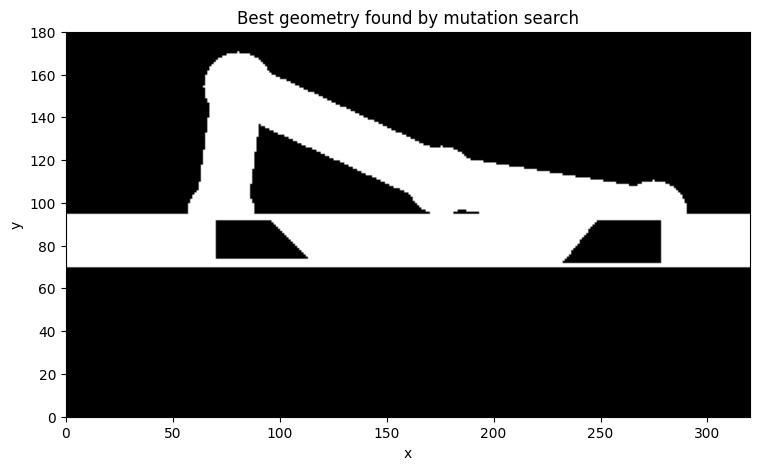

,name,score,Re_proxy,q_forward,q_reverse,Dq_qrev_qfwd,Z_forward,Z_reverse,DZ_zrev_zfwd,dP_forward,dP_reverse,DP_ratio,A_q,A_Z,alpha_forward,alpha_reverse,theta_forward_deg,theta_reverse_deg
0,base,2.546068,75.0,0.010994,0.036996,3.365104,1.298489,1.726977,1.329990,1.298489,1.726977,1.329990,0.541821,0.141627,0.104519,0.340573,64.290046,33.690068
1,top,4.237178,75.0,0.010270,0.070175,6.833315,1.276244,2.375925,1.861654,1.276244,2.375925,1.861654,0.744680,0.301104,0.053714,0.548408,82.405357,9.180542


Saved: tesla_valve_nexus_v2_outputs\tesla_v2_top_geometries.json


In [16]:
# ============================================================
# 6. Geometry mutation search
# ============================================================
# Goal: search for geometries where reverse branch angle is shallow
# and forward branch angle is steep, producing strong directional lock.

def mutate_geom(base: TeslaGeom, rng, scale=18):
    g = TeslaGeom(**asdict(base))

    U1x, U1y = g.U1
    U2x, U2y = g.U2

    U1x += int(rng.normal(0, scale))
    U1y += int(rng.normal(0, scale))
    U2x += int(rng.normal(0, scale))
    U2y += int(rng.normal(0, scale))

    # Keep branch above main channel and inside domain.
    U1x = int(np.clip(U1x, 80, 150))
    U2x = int(np.clip(U2x, 175, 250))
    U1y = int(np.clip(U1y, 115, g.ny - 25))
    U2y = int(np.clip(U2y, 110, g.ny - 25))

    g.U1 = (U1x, U1y)
    g.U2 = (U2x, U2y)

    return g


def geometry_score(g: TeslaGeom, Re=DEFAULT_RE):
    _, _, s = compare_cases(Re, g)

    # Reward reverse > forward. Penalize reciprocal or inverted cases.
    score = (
        math.log(s["Dq_qrev_qfwd"] + EPS)
        + 0.75 * math.log(s["DZ_zrev_zfwd"] + EPS)
        + 1.50 * s["A_q"]
    )

    # Reward angular separation: forward entry steep, reverse entry shallow.
    score += 0.01 * (s["theta_forward_deg"] - s["theta_reverse_deg"])

    return score, s


def search_geometries(base=geom, n=120, seed=7, Re=DEFAULT_RE):
    rng = np.random.default_rng(seed)
    records = []

    # include base
    score, s = geometry_score(base, Re)
    records.append({"score": score, "geom": base, **s})

    for _ in range(n):
        g = mutate_geom(base, rng)
        score, s = geometry_score(g, Re)
        records.append({"score": score, "geom": g, **s})

    records = sorted(records, key=lambda d: d["score"], reverse=True)
    return records


records = search_geometries(n=160, Re=DEFAULT_RE)
top = records[0]

print("Top geometry score:", top["score"])
print("Top metrics:")
for k, v in top.items():
    if k != "geom":
        print(f"  {k}: {v}")
print("Top geometry:")
print(json.dumps(asdict(top["geom"]), indent=2))

# Display top geometry.
fig, ax = plt.subplots(figsize=(12, 5))
plot_geometry(top["geom"], ax=ax, title="Best geometry found by mutation search")
plt.show()

# Compare base vs top.
base_score, base_s = geometry_score(geom, DEFAULT_RE)
rows = [
    {"name": "base", "score": base_score, **base_s},
    {"name": "top", "score": top["score"], **{k: v for k, v in top.items() if k != "geom"}},
]
compare_df = pd.DataFrame(rows)
display(compare_df)

if SAVE_RESULTS:
    # Save only serializable values.
    serial = []
    for rec in records[:20]:
        serial.append({
            "score": rec["score"],
            "geom": asdict(rec["geom"]),
            **{k: v for k, v in rec.items() if k not in ("score", "geom")}
        })
    with open(OUTDIR / "tesla_v2_top_geometries.json", "w", encoding="utf-8") as fobj:
        json.dump(serial, fobj, indent=2)
    print(f"Saved: {OUTDIR / 'tesla_v2_top_geometries.json'}")

BEST GEOMETRY — DIRECTIONAL LOCK
Re_proxy             75.000000
q_forward             0.010270
q_reverse             0.070175
Dq_qrev_qfwd          6.833315
Z_forward             1.276244
Z_reverse             2.375925
DZ_zrev_zfwd          1.861654
dP_forward            1.276244
dP_reverse            2.375925
DP_ratio              1.861654
A_q                   0.744680
A_Z                   0.301104
alpha_forward         0.053714
alpha_reverse         0.548408
theta_forward_deg    82.405357
theta_reverse_deg     9.180542
Saved: tesla_valve_nexus_v2_outputs\tesla_v2_best_forward.png


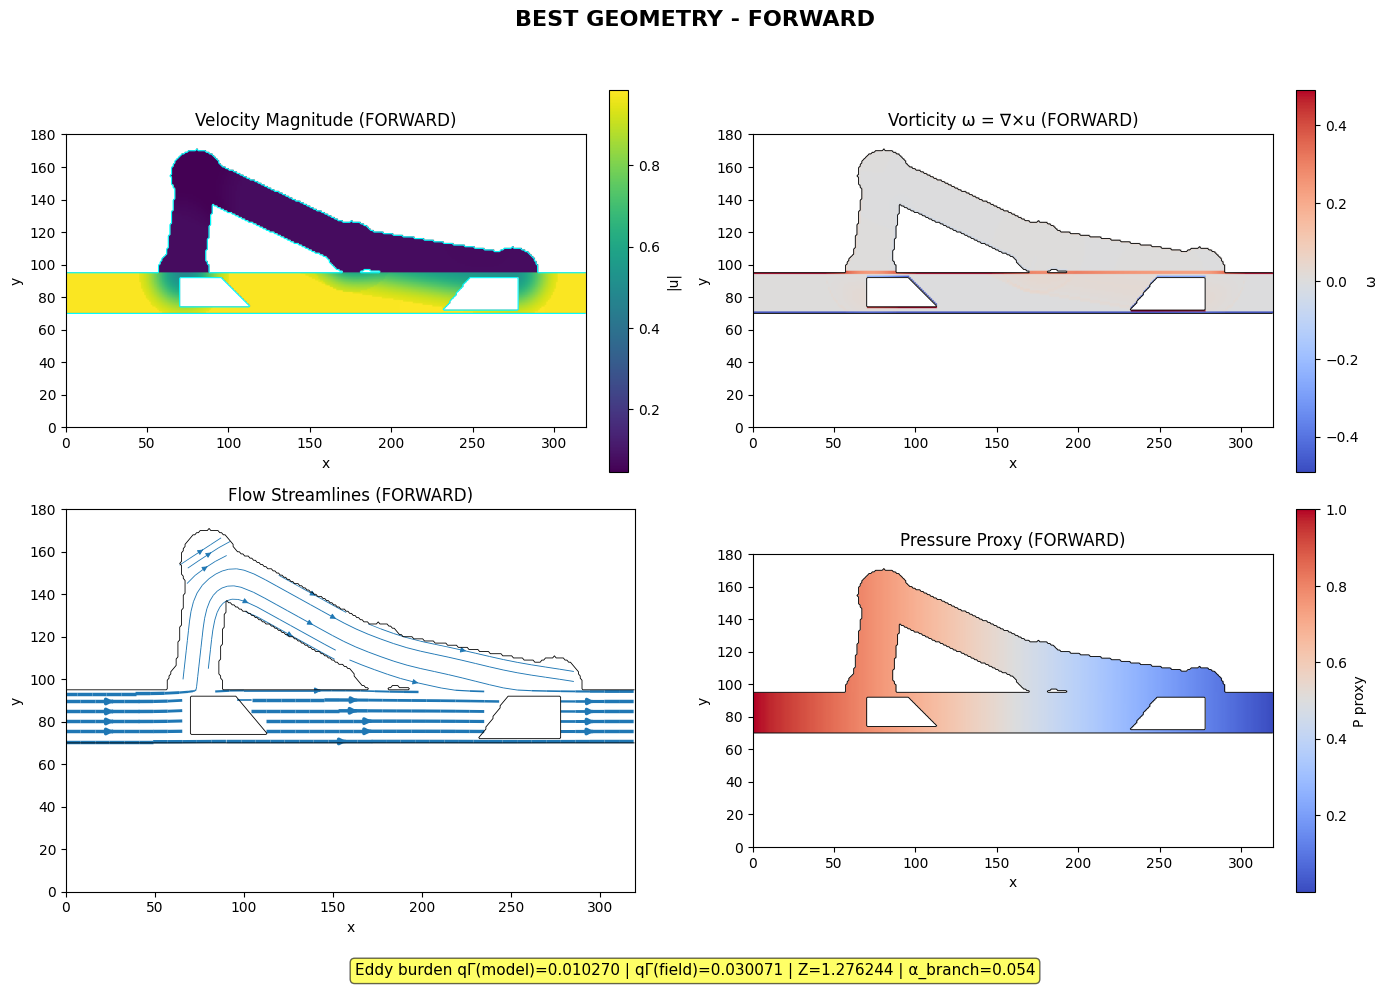

Saved: tesla_valve_nexus_v2_outputs\tesla_v2_best_reverse.png


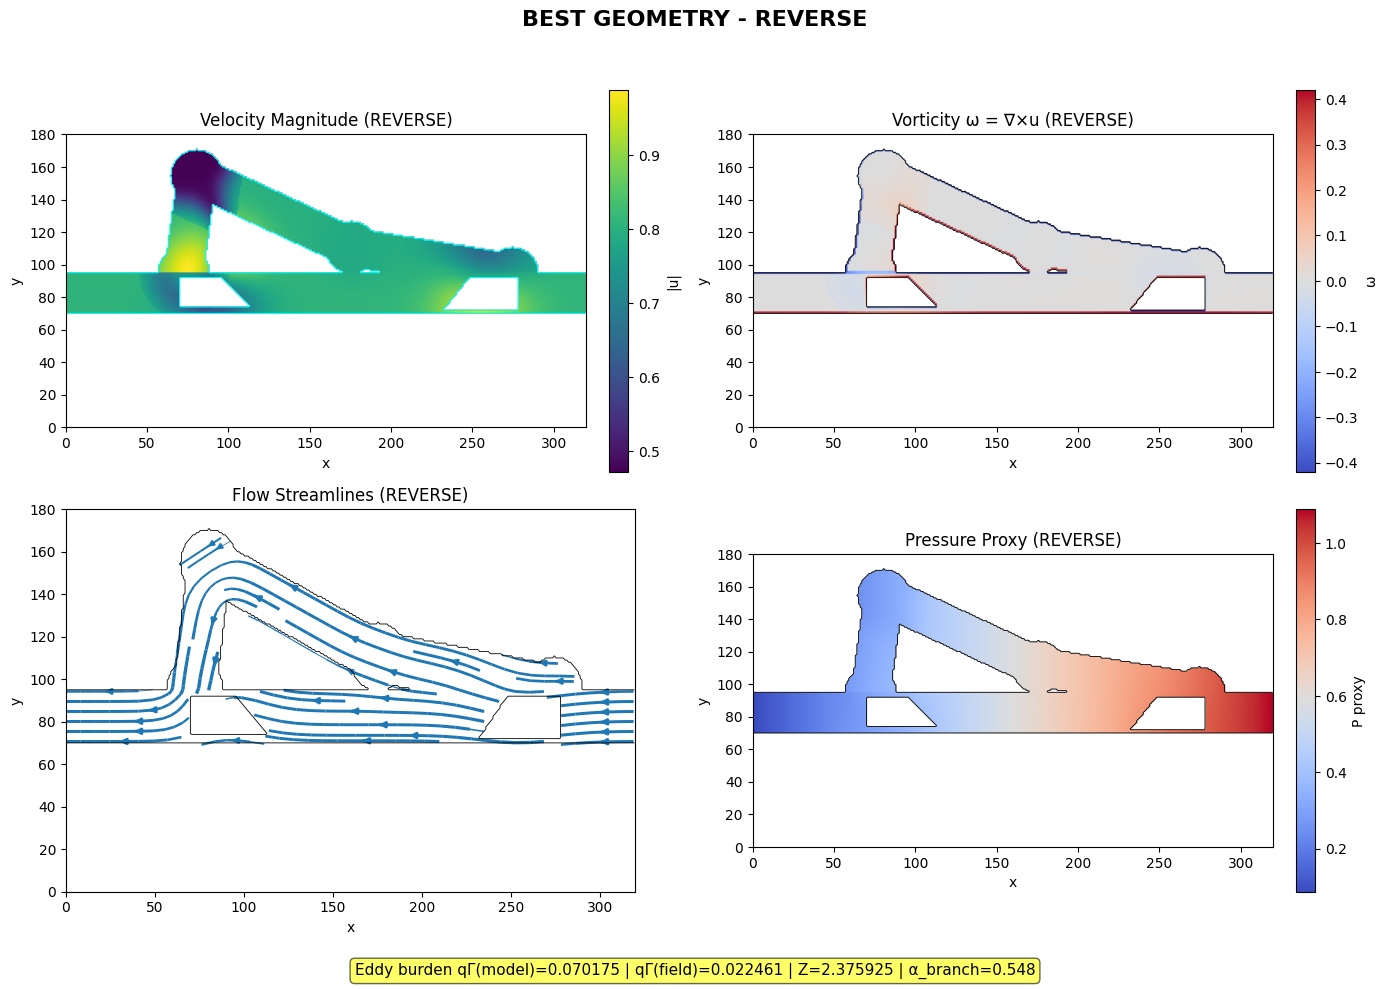

In [17]:
# ============================================================
# 7. Run the best geometry from mutation search
# ============================================================

best_geom = top["geom"]
best_Re = DEFAULT_RE

best_forward = render_field("forward", Re=best_Re, geom=best_geom)
best_reverse = render_field("reverse", Re=best_Re, geom=best_geom)
bf, br, bs = compare_cases(best_Re, best_geom)

print("=" * 72)
print("BEST GEOMETRY — DIRECTIONAL LOCK")
print("=" * 72)
print(pd.Series(bs).to_string())

fig1 = plot_case(best_forward, title="BEST GEOMETRY - FORWARD", save_path=OUTDIR / "tesla_v2_best_forward.png" if SAVE_RESULTS else None)
plt.show()

fig2 = plot_case(best_reverse, title="BEST GEOMETRY - REVERSE", save_path=OUTDIR / "tesla_v2_best_reverse.png" if SAVE_RESULTS else None)
plt.show()

In [18]:
# ============================================================
# 8. Optional LBM starter cell
# ============================================================
# Disabled by default because this is slower and more sensitive.
#
# This is included as a sanity-check path:
# - It should be used after the reduced-order geometry locks.
# - If LBM stays reciprocal, the raster geometry is not producing
#   enough inertial separation at the selected scale/forcing.
#
# Set RUN_LBM = True to run.

RUN_LBM = False

def lbm_feq(rho, ux, uy):
    c = np.array(
        [[0,0],[1,0],[0,1],[-1,0],[0,-1],[1,1],[-1,1],[-1,-1],[1,-1]],
        dtype=int
    )
    w = np.array([4/9,1/9,1/9,1/9,1/9,1/36,1/36,1/36,1/36], dtype=float)
    out = np.empty(rho.shape + (9,), dtype=float)
    u2 = ux * ux + uy * uy
    for i, (cx, cy) in enumerate(c):
        cu = cx * ux + cy * uy
        out[..., i] = w[i] * rho * (1 + 3 * cu + 4.5 * cu * cu - 1.5 * u2)
    return out


def lbm_simulate(fluid, force_x=2e-6, tau=0.72, steps=1200):
    """
    Minimal D2Q9 BGK LBM with body force and simple full-way bounce-back.
    Periodic x boundary, solid walls/obstacles from the mask.
    """
    c = np.array(
        [[0,0],[1,0],[0,1],[-1,0],[0,-1],[1,1],[-1,1],[-1,-1],[1,-1]],
        dtype=int
    )
    w = np.array([4/9,1/9,1/9,1/9,1/9,1/36,1/36,1/36,1/36], dtype=float)
    opp = np.array([0,3,4,1,2,7,8,5,6], dtype=int)

    solid = ~fluid
    ny, nx = fluid.shape

    rho = np.ones((ny, nx), dtype=float)
    ux = np.zeros((ny, nx), dtype=float)
    uy = np.zeros((ny, nx), dtype=float)

    f = lbm_feq(rho, ux, uy)

    for step in range(steps):
        rho = np.sum(f, axis=2)
        rho[solid] = 1.0

        ux = (np.tensordot(f, c[:, 0], axes=(2, 0)) + 0.5 * force_x) / rho
        uy = np.tensordot(f, c[:, 1], axes=(2, 0)) / rho
        ux[solid] = 0.0
        uy[solid] = 0.0

        fe = lbm_feq(rho, ux, uy)

        # Guo-style forcing, x only.
        Fi = np.empty_like(f)
        for i, (cx, cy) in enumerate(c):
            ciu = cx * ux + cy * uy
            term = 3 * (cx - ux) * force_x + 9 * ciu * cx * force_x
            Fi[..., i] = w[i] * (1 - 0.5 / tau) * term

        f_coll = f - (f - fe) / tau + Fi

        # Full-way bounce-back at solid nodes.
        f_coll[solid, :] = f[solid, :][:, opp]

        f_stream = np.empty_like(f)
        for i, (cx, cy) in enumerate(c):
            f_stream[..., i] = np.roll(np.roll(f_coll[..., i], cy, axis=0), cx, axis=1)

        f_stream[solid, :] = f_stream[solid, :][:, opp]
        f = f_stream

        if not np.all(np.isfinite(f)):
            raise FloatingPointError(f"LBM diverged at step {step}")

    rho = np.sum(f, axis=2)
    ux = np.tensordot(f, c[:, 0], axes=(2, 0)) / rho
    uy = np.tensordot(f, c[:, 1], axes=(2, 0)) / rho

    ux[solid] = np.nan
    uy[solid] = np.nan
    rho[solid] = np.nan

    speed = np.sqrt(ux ** 2 + uy ** 2)
    omega = np.gradient(np.nan_to_num(uy), axis=1) - np.gradient(np.nan_to_num(ux), axis=0)
    omega[solid] = np.nan

    q = np.nanmean(omega[fluid] ** 2) / (np.nanmean(speed[fluid] ** 2) + EPS)
    Q = np.nanmean(ux[fluid])
    Z = abs(force_x) / (abs(Q) + EPS)

    return {
        "rho": rho,
        "U": ux,
        "V": uy,
        "speed": speed,
        "omega": omega,
        "qGamma_lbm": q,
        "Q_lbm": Q,
        "Z_lbm": Z,
        "fluid": fluid,
    }


if RUN_LBM:
    print("Running optional LBM. This can take a few minutes.")
    lbm_geom = best_geom
    lbm_fluid = make_tesla_fluid_mask(lbm_geom)

    lbm_f = lbm_simulate(lbm_fluid, force_x=+2e-6, tau=0.72, steps=1200)
    lbm_r = lbm_simulate(lbm_fluid, force_x=-2e-6, tau=0.72, steps=1200)

    qf = lbm_f["qGamma_lbm"]
    qr = lbm_r["qGamma_lbm"]
    zf = lbm_f["Z_lbm"]
    zr = lbm_r["Z_lbm"]

    print("LBM RESULTS")
    print(f"q_forward={qf:.6g}, q_reverse={qr:.6g}, Dq={qr/(qf+EPS):.6g}")
    print(f"Z_forward={zf:.6g}, Z_reverse={zr:.6g}, DZ={zr/(zf+EPS):.6g}")

    # Quick plot.
    for name, out in [("forward", lbm_f), ("reverse", lbm_r)]:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        axes[0].imshow(out["speed"], origin="lower")
        axes[0].contour(out["fluid"].astype(float), levels=[0.5], colors="w", linewidths=0.5, origin="lower")
        axes[0].set_title(f"LBM speed - {name}")

        vmax = np.nanpercentile(np.abs(out["omega"]), 98)
        axes[1].imshow(out["omega"], origin="lower", cmap="coolwarm", vmin=-vmax, vmax=vmax)
        axes[1].contour(out["fluid"].astype(float), levels=[0.5], colors="k", linewidths=0.5, origin="lower")
        axes[1].set_title(f"LBM vorticity - {name}")
        plt.tight_layout()
        plt.show()
else:
    print("RUN_LBM is False. Optional LBM cell skipped.")

RUN_LBM is False. Optional LBM cell skipped.


## Ψ interpretation

Read the sweep like this:

- If $D_q \approx 1$ and $D_Z \approx 1$, the valve is still operationally reciprocal.
- If $D_q > 1.25$ and $D_Z > 1.10$, the geometry is beginning to fold direction into structure.
- If $D_q > 2$, the side loop is carrying real reverse eddy burden.

The notebook is intentionally transparent: the reduced-order model is not full CFD. It is the fast **geometry/trust diagnostic**. The LBM starter is there to test whether the rasterized shape also creates non-reciprocity under a simple lattice-flow solver.

Nexus read:

$$
\Delta_{\text{direction}} \oplus \Gamma_{\text{geometry}}
\rightarrow
\begin{cases}
\Phi_F & \text{pass-through}\\
\Phi_R & \text{self-interference}
\end{cases}
\rightarrow
\Psi
$$

When the geometry is right:

$$
q_{\Gamma,R} > q_{\Gamma,F}
$$

When the geometry is wrong:

$$
q_{\Gamma,R} \approx q_{\Gamma,F}
$$

That is the operational lock.